## Machine Learning Model Training
This code trains the machine learning models and evaluates the best model based on their accuracy.

### Importing Libraries
For this project, we will work with the KNN Classifier and the Random Forest Classifier, and evaluate which of them is the best for our project.
We load `FEATURES_FILE` file and define the `CLASSES`

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib


from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

FEATURES_FILE = 'Features_Dataset.csv'
CLASSES = ['0','1','2', '3', '4', '5', '6', '7', '8', '9', '=', '+', '-']

## Train Test Split
Here, we load the data and we split the data into an 80:20 ratio, which means that 80% of the data is used for training and
20% of the data is used for testing.
We shuffle the data so that the model does not learn any patters from the dataset itself.
We also scale the features to aide the `KNN Model`.

In [7]:
df = pd.read_csv(FEATURES_FILE)
X  = df.drop(columns=['label']).values
y  = df['label'].values
print(f"Loaded: {X.shape[0]} samples, {X.shape[1]} features")

X, y = shuffle(X, y, random_state = 42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state=42)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Loaded: 845 samples, 42 features


### Training KNN
Here, we train the KNN Model and print its accuracy and the classification report

In [8]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_sc, y_train)

acc = knn.score(X_test_sc, y_test)

print(f"Accuracy: {acc*100:.1f}%")
print(classification_report(y_test, knn.predict(X_test_sc)))

Accuracy: 71.0%
              precision    recall  f1-score   support

           +       1.00      1.00      1.00         6
           -       1.00      0.93      0.97        15
           0       0.53      0.53      0.53        15
           1       0.88      0.93      0.90        15
           2       0.46      0.73      0.56        15
           3       0.50      0.54      0.52        13
           4       0.71      0.42      0.53        12
           5       0.89      0.67      0.76        12
           6       0.50      0.67      0.57        12
           7       1.00      0.75      0.86        12
           8       0.73      0.92      0.81        12
           9       0.64      0.58      0.61        12
           =       0.92      0.67      0.77        18

    accuracy                           0.71       169
   macro avg       0.75      0.72      0.72       169
weighted avg       0.74      0.71      0.72       169



### Confusion Matrix for KNN
Here, we generate a confusion matrix for the KNN Model to better understand the merits of the model and where the model seems to be lacking.

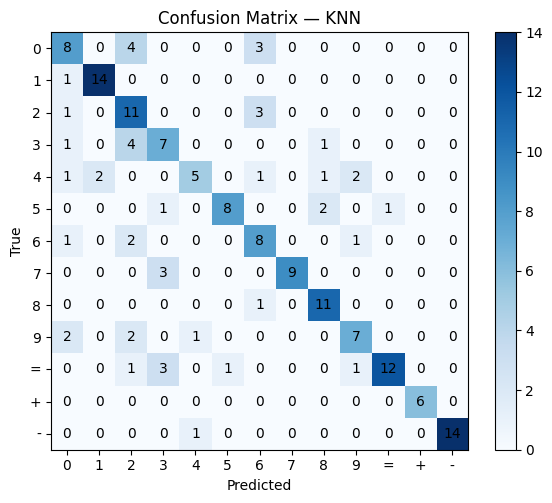

In [10]:
y_pred = knn.predict(X_test_sc)

cm = confusion_matrix(y_test, y_pred, labels=CLASSES)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES)
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
plt.colorbar(im, ax=ax)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, cm[i,j], ha='center', va='center', color='black')
plt.title('Confusion Matrix — KNN')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

### Training Random Forest
Here, we train the Random Forest Model and print its accuracy and the classification report

In [11]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)

acc_rf = rf.score(X_test_sc, y_test)
print(f"Random Forest Accuracy: {acc_rf*100:.1f}%")
print(classification_report(y_test, rf.predict(X_test_sc)))

Random Forest Accuracy: 87.0%
              precision    recall  f1-score   support

           +       1.00      1.00      1.00         6
           -       1.00      1.00      1.00        15
           0       0.86      0.80      0.83        15
           1       0.88      1.00      0.94        15
           2       0.83      0.67      0.74        15
           3       0.73      0.85      0.79        13
           4       0.75      0.75      0.75        12
           5       0.83      0.83      0.83        12
           6       0.86      1.00      0.92        12
           7       1.00      0.67      0.80        12
           8       0.86      1.00      0.92        12
           9       1.00      0.75      0.86        12
           =       0.86      1.00      0.92        18

    accuracy                           0.87       169
   macro avg       0.88      0.87      0.87       169
weighted avg       0.88      0.87      0.87       169



### Confusion Matrix for Random Forest
Here, we generate a confusion matrix for the Random Forest Model to better understand the merits of the model and where the model seems to be lacking.

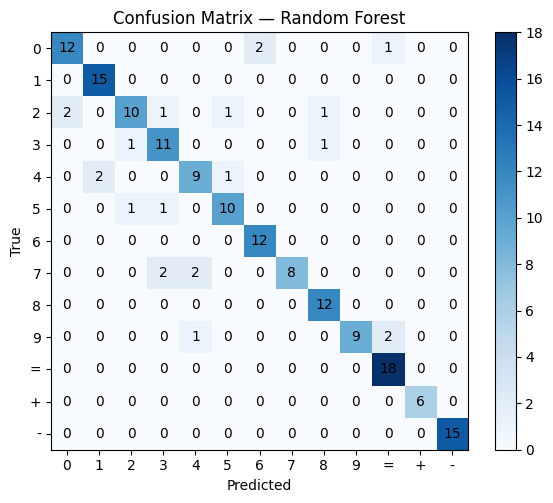

In [12]:
y_pred = rf.predict(X_test_sc)

CLASSES_CM = CLASSES

cm = confusion_matrix(y_test, y_pred, labels=CLASSES_CM)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASSES_CM))); ax.set_xticklabels(CLASSES_CM)
ax.set_yticks(range(len(CLASSES_CM))); ax.set_yticklabels(CLASSES_CM)
plt.colorbar(im, ax=ax)
for i in range(len(CLASSES_CM)):
    for j in range(len(CLASSES_CM)):
        ax.text(j, i, cm[i,j], ha='center', va='center', color='black')
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

### Comparison of Models
The models are compared, and the best fitting model is selected.

In [13]:
# Summary comparison
print(f"KNN           → {acc*100:.1f}%")
print(f"Random Forest → {acc_rf*100:.1f}%")

KNN           → 71.0%
Random Forest → 87.0%


### Saving the Model
After confirming which model works the best for the dataset, the model is saved, along with the scaler file.

In [14]:
# Save model and scaler
joblib.dump(rf,    'gesture_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Saved gesture_model.pkl and scaler.pkl")

Saved gesture_model.pkl and scaler.pkl
